# Milestone 1: Week 5 - Support Vector Machines, the Kernel Trick, and Regularization for Support Vector Machines

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

In [8]:
random_state = 42

In [15]:
socioeconomic = pd.read_csv(r"..\Processed Data\USDA Socioeconomic Indicators.csv")
socioeconomic.head()

,FIPS_Code,State,Area_Name,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
0,0,US,United States,2000,142601576.0,136904853.0,100.0,74755.0,1.0,2.0,5696723.0,3.994853,2.0
1,0,US,United States,2001,143786537.0,136977996.0,100.0,74755.0,1.0,2.0,6808541.0,4.735173,2.0
2,0,US,United States,2002,144839298.0,136455783.0,100.0,74755.0,1.0,2.0,8383515.0,5.788149,2.0
3,0,US,United States,2003,145660094.0,136944522.0,100.0,74755.0,1.0,2.0,8715572.0,5.983500,2.0
4,0,US,United States,2004,146724795.0,138613904.0,100.0,74755.0,1.0,2.0,8110891.0,5.527962,2.0


In [17]:
# ignoring macro samples (entire US and state aggregates) to avoid data leakage
states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado','Connecticut','Delaware','Florida','Georgia'
         ,'Hawaii','Idaho','Illinois','Indiana','Iowa','Kansas','Kentucky','Louisiana','Maine','Maryland'
         ,'Massachusetts','Michigan','Minnesota','Mississippi','Missouri','Montana','Nebraska','Nevada','New Hampshire','New Jersey'
         ,'New Mexico','New York','North Carolina','North Dakota','Ohio','Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina'
         ,'South Dakota','Tennessee','Texas','Utah','Vermont','Virginia','Washington','West Virginia','Wisconsin','Wyoming']

socioeconomic = socioeconomic[(socioeconomic['FIPS_Code'] != 0) & (socioeconomic['State'] != 'US') & (socioeconomic['Area_Name'] != 'United States') & (~socioeconomic['Area_Name'].isin(states))]
socioeconomic.head()

,FIPS_Code,State,Area_Name,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
48,1001,AL,"Autauga County, AL",2000,21861.0,20971.0,117.5,70148.0,1.0,2.0,890.0,4.071177,2.0
49,1001,AL,"Autauga County, AL",2001,22081.0,21166.0,117.5,70148.0,1.0,2.0,915.0,4.143834,2.0
50,1001,AL,"Autauga County, AL",2002,22161.0,21096.0,117.5,70148.0,1.0,2.0,1065.0,4.805740,2.0
51,1001,AL,"Autauga County, AL",2003,22695.0,21557.0,117.5,70148.0,1.0,2.0,1138.0,5.014320,2.0
52,1001,AL,"Autauga County, AL",2004,23241.0,22146.0,117.5,70148.0,1.0,2.0,1095.0,4.711501,2.0


In [24]:
socioeconomic = socioeconomic.select_dtypes(include='number')

X = socioeconomic.drop(columns=['Metro', 'Rural_Urban_Continuum_Code', 'Urban_Influence_Code', 'FIPS_Code']) # Dropping Metro (target) and features that will leak to the model how to determine metro/rural
y = socioeconomic['Metro']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [25]:
SVC_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma="scale")
)

param_grid = {
    'svc__C': [0.001, 0.01, 0.1, 1.0],
    'svc__gamma': [0.001, 0.01, 0.1]
}

SVC_grid_search = GridSearchCV(SVC_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
SVC_grid_search.fit(X_train, y_train)

print(f"SVC Best Parameters: {SVC_grid_search.best_params_}")
print(f"SVC Best Accuracy: {SVC_grid_search.best_score_:.4f}")

SVC Best Parameters: {'svc__C': 1.0, 'svc__gamma': 0.1}
SVC Best Accuracy: 0.8228


In [30]:
C = 1.0
gamma = 0.1

SVC_model_optimized = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=C, gamma=gamma)
)

SVC_model_optimized.fit(X_train, y_train)

distances = SVC_model_optimized.decision_function(X_test)
y_pred = SVC_model_optimized.predict(X_test)

outlier_df = X_test.copy()
outlier_df['Actual Metro'] = y_test
outlier_df['Predicted Metro'] = y_pred
outlier_df['Boundary Distance'] = distances
outlier_df['Anomaly Confidence'] = np.abs(distances)

outliers = outlier_df[outlier_df['Actual Metro'] != outlier_df['Predicted Metro']]
outliers = outliers.sort_values(by='Anomaly Confidence', ascending=False)

In [31]:
outliers

,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Unemployed,Unemployment_rate,Actual Metro,Predicted Metro,Boundary Distance,Anomaly Confidence
7870,2020,107207.0,99528.0,99.1,81188.0,7679.0,7.162779,0.0,1.0,4.745655,4.745655
7872,2022,112168.0,107494.0,99.1,81188.0,4674.0,4.166964,0.0,1.0,4.452194,4.452194
7868,2018,105605.0,101702.0,99.1,81188.0,3903.0,3.695848,0.0,1.0,4.218746,4.218746
55851,2015,80814.0,75509.0,111.2,79824.0,5305.0,6.564457,0.0,1.0,4.099809,4.099809
55850,2014,79784.0,73693.0,111.2,79824.0,6091.0,7.634363,0.0,1.0,4.033465,4.033465
...,...,...,...,...,...,...,...,...,...,...,...
76515,2015,22556.0,21509.0,106.3,75779.0,1047.0,4.641780,0.0,1.0,0.003254,0.003254
20785,2023,8924.0,8615.0,116.0,80887.0,309.0,3.462573,1.0,0.0,-0.001045,0.001045
43110,2018,41139.0,40059.0,84.0,76227.0,1080.0,2.625246,0.0,1.0,0.001008,0.001008
18454,2020,22895.0,20947.0,104.2,69567.0,1948.0,8.508408,0.0,1.0,0.000806,0.000806


In [45]:
outliers['Anomaly Confidence'].describe()

count    2748.000000
mean        0.798995
std         0.460002
min         0.000009
25%         0.445036
50%         0.866752
75%         1.113453
max         4.745655
Name: Anomaly Confidence, dtype: float64

In [ ]:
# using PCA to visualize a reduced dimensionality of all data points in order to visualize what the SVC model marked as outliers
from sklearn.decomposition import PCA

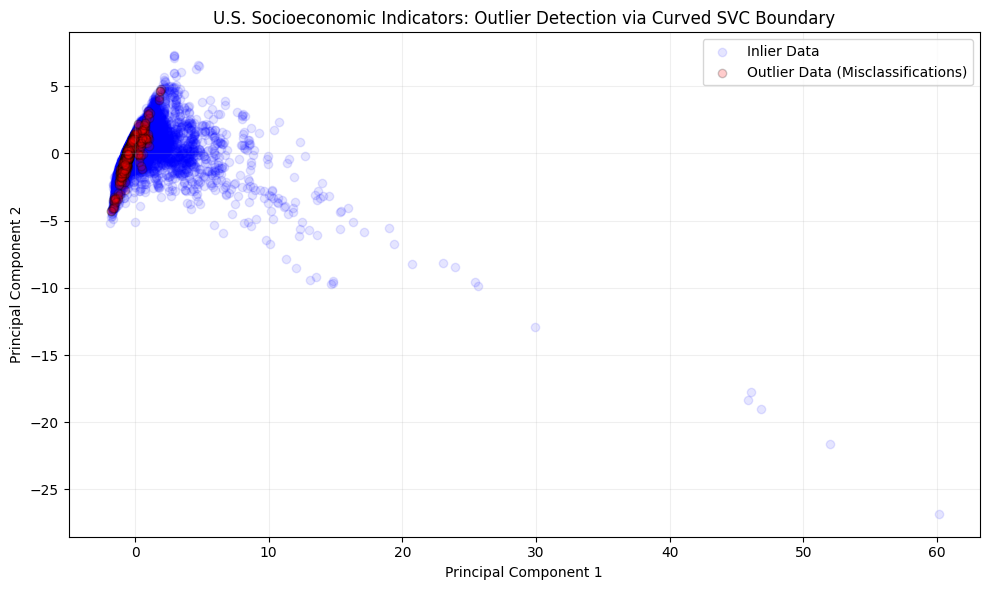

In [46]:
scaler = SVC_model_optimized.named_steps['standardscaler']
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# PCA coordinates
outlier_df['PCA Component 1'] = X_test_pca[:, 0]
outlier_df['PCA Component 2'] = X_test_pca[:, 1]

inliers_plot = outlier_df[outlier_df['Actual Metro'] == outlier_df['Predicted Metro']]

# establish outliers as greater than quantile to get the most significantly "large" abs(distances) 
outliers_plot = outlier_df[outlier_df['Actual Metro'] != outlier_df['Predicted Metro']]
confidence_threshold = outliers_plot['Anomaly Confidence'].quantile(0.75)
outliers_plot = outliers_plot[outliers_plot['Anomaly Confidence'] >= confidence_threshold]

fig, ax = plt.subplots(figsize=(10,6))

# inliers
ax.scatter(
    inliers_plot['PCA Component 1'],
    inliers_plot['PCA Component 2'],
    c='blue',
    alpha=0.1,
    label='Inlier Data'
)

# outliers
ax.scatter(
    outliers_plot['PCA Component 1'],
    outliers_plot['PCA Component 2'],
    c='red',
    alpha=0.2,
    edgecolors='black',
    label='Outlier Data (Misclassifications)'
)

ax.set_title('U.S. Socioeconomic Indicators: Outlier Detection via Curved SVC Boundary')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

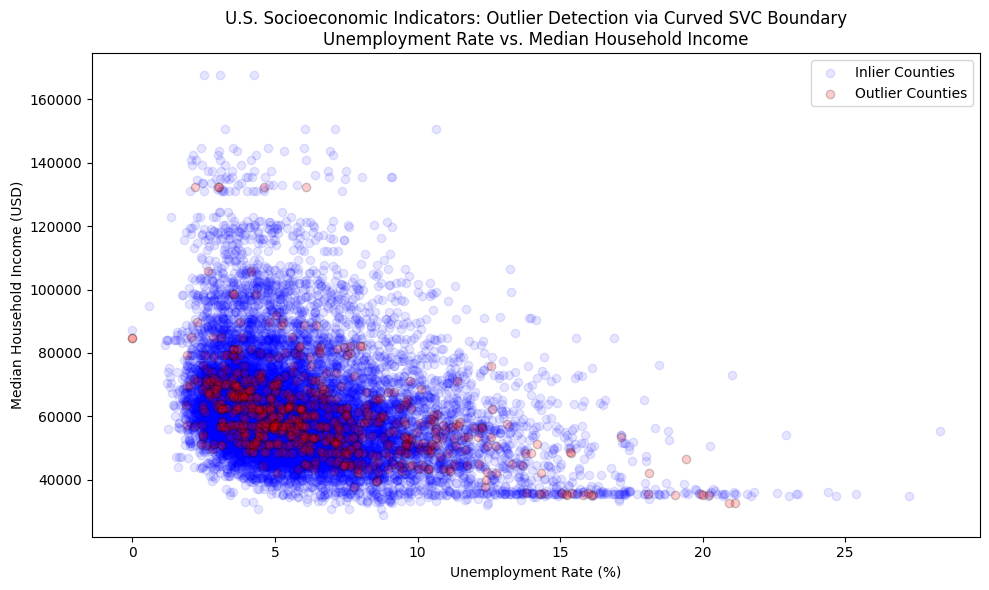

In [47]:
# Let's visualize the outliers but specifically with two features for better interpretability

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(inliers_plot['Unemployment_rate'], inliers_plot['Median_Household_Income'], c='blue', alpha=0.1, label='Inlier Counties')
ax.scatter(outliers_plot['Unemployment_rate'], outliers_plot['Median_Household_Income'], c='red', edgecolors='black', alpha=0.2, label='Outlier Counties')

ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Median Household Income (USD)')
ax.set_title('U.S. Socioeconomic Indicators: Outlier Detection via Curved SVC Boundary\nUnemployment Rate vs. Median Household Income')
ax.legend()
plt.tight_layout()
plt.show()

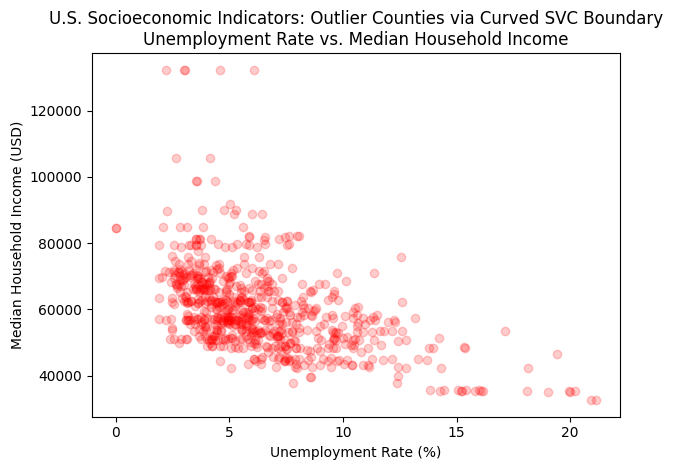

In [49]:
plt.scatter(outliers_plot['Unemployment_rate'], outliers_plot['Median_Household_Income'], color='red', alpha=0.2)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Median Household Income (USD)')
plt.title('U.S. Socioeconomic Indicators: Outlier Counties via Curved SVC Boundary\nUnemployment Rate vs. Median Household Income')
plt.tight_layout()
plt.show()

In [55]:
features_to_check = X.columns.tolist()

inlier_median = inliers_plot[features_to_check].median()
outlier_median = outliers_plot[features_to_check].median()
percent_diff = ((outlier_median - inlier_median) / inlier_median) * 100

profiles_comparison = pd.DataFrame({
    'Median Inlier': inlier_median,
    'Median Outlier': outlier_median,
    'Outlier % Difference': percent_diff
})

print("========== OUTLIER SOCIOECONOMIC PROFILE COMPARISONS ==========")
profiles_comparison

========== OUTLIER SOCIOECONOMIC PROFILE COMPARISONS ==========


,Median Inlier,Median Outlier,Outlier % Difference
Year,2011.000000,2012.000000,0.049727
Civilian_labor_force,11356.000000,6825.000000,-39.899613
Employed,10627.000000,6411.000000,-39.672532
Med_HH_Income_Percent_of_State_Total,85.700000,84.500000,-1.400233
Median_Household_Income,60108.000000,57855.000000,-3.748253
Unemployed,675.000000,398.000000,-41.037037
Unemployment_rate,5.222157,5.697151,9.095757


In [52]:
top_anomalies = outliers_plot.head(10)
top_anomalies

,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Unemployed,Unemployment_rate,Actual Metro,Predicted Metro,Boundary Distance,Anomaly Confidence,PCA Component 1,PCA Component 2
1333,2013,7415.0,6713.0,76.1,45440.0,702.0,9.467296,1.0,0.0,-1.257017,1.257017,-0.931246,-1.298256
61206,2018,9215.0,8936.0,98.1,63960.0,279.0,3.027672,1.0,0.0,-1.132553,1.132553,-0.153016,1.010252
11735,2021,3525.0,3382.0,95.9,69776.0,143.0,4.056738,1.0,0.0,-1.126873,1.126873,-0.137392,1.025256
33248,2020,12952.0,11838.0,79.3,65294.0,1114.0,8.600988,1.0,0.0,-1.131246,1.131246,-0.435027,-0.368719
59557,2001,7497.0,7163.0,88.5,57732.0,334.0,4.455115,1.0,0.0,-1.166642,1.166642,-0.474635,0.123082
61686,2018,9498.0,8930.0,83.7,60523.0,568.0,5.980206,1.0,0.0,-1.146038,1.146038,-0.455932,0.014756
74964,2000,43287.0,42041.0,110.8,78728.0,1246.0,2.878462,0.0,1.0,1.182497,1.182497,0.514910,1.568479
41479,2019,3413.0,3291.0,99.4,69423.0,122.0,3.574568,1.0,0.0,-1.163900,1.163900,-0.094000,1.167908
17182,2020,4169.0,3942.0,93.2,62248.0,227.0,5.444951,1.0,0.0,-1.148640,1.148640,-0.336274,0.468720
72713,2005,5023.0,4618.0,90.0,82132.0,405.0,8.062911,1.0,0.0,-1.126222,1.126222,-0.100342,0.439081


My outlier detection algorithm using an SVM with the kernel trick allows me to detect outlier counties where the boundary line is between `Metro` and `Rural` counties. Socioeconomic conditions of all counties in the U.S. do not always share a simple, linear relationship. These features interact in complex relationship clusters. Because of this, the RBF kernel was used because it doesn't consider the global trend and instead measures the local similarity between data points. It is useful for this dataset because it captures instances where variables behave normally in one region of the feature space but shifts in another. From my PCA visualization, you can see that the outlier data points are positioned in a sharp line on the upper left side of the main data mass. The red points are statistical contradictions such as `Rural` counties clustering within the core `Metro` counties for its multi-dimensional socioeconomic conditions (or vice versa). Based on the 75% quantile of SVM boundary distances, these are the more confident outlier data points due to the distances being much larger than sitting close to the boundary.

If you simply switch from looking at the PCA visualization to visualizing two specific features, it becomes less clear on how the outlier counties are marked as outliers because you are not considering the multi-dimensional context as to why they are outliers. By looking at the median inlier profile and median high confidence outlier profile there are some key insights that may help to better understand the SVM anomaly detection algorithm I created. For example, we see there is a significant decrease in `Civilian_labor_force`, `Employed`, and `Unemployed` (39.9%, 39.7%, 41.0% respectively).